Binary Image Matrix:

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


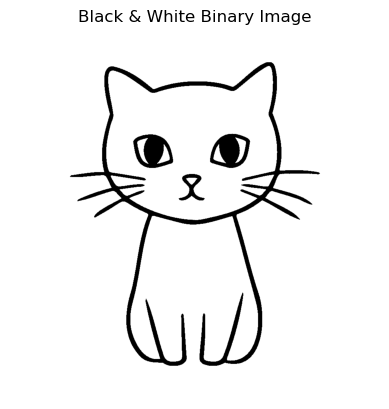

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Load the image
image_path = r"C:\\Users\\soumy\\Downloads\\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"
img = Image.open(image_path)

# Step 2: Convert to grayscale
gray = img.convert("L")

# Step 3: Convert to numpy array
img_array = np.array(gray)

# Step 4: Convert to binary (black = 0, white = 1)
binary_image = np.where(img_array > 128, 1, 0)

# Step 5: Print matrix
print("Binary Image Matrix:\n")
print(binary_image)

# Step 6: Display the binary image
plt.imshow(binary_image, cmap='gray')
plt.title("Black & White Binary Image")
plt.axis("off")
plt.show()


Binary Image Matrix:

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


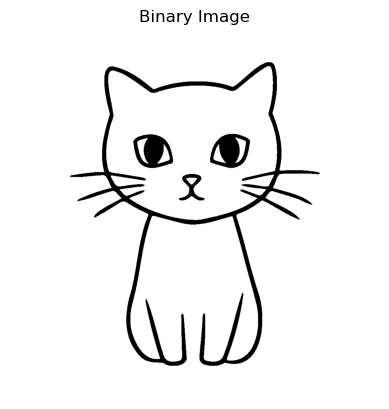

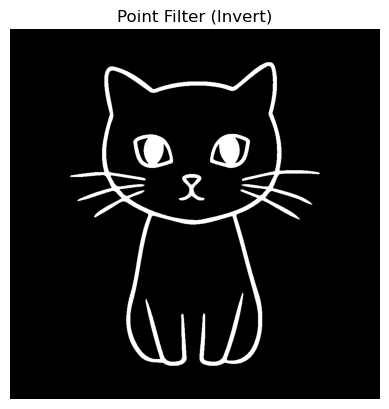

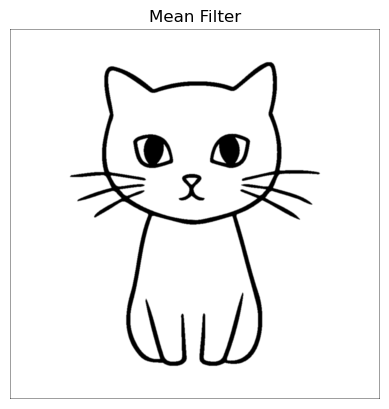

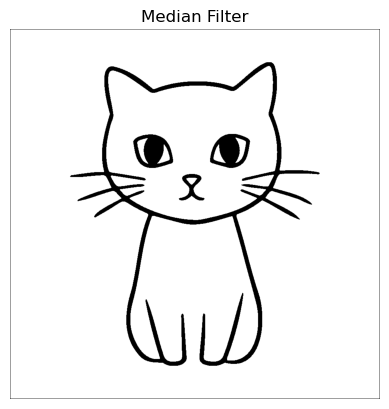

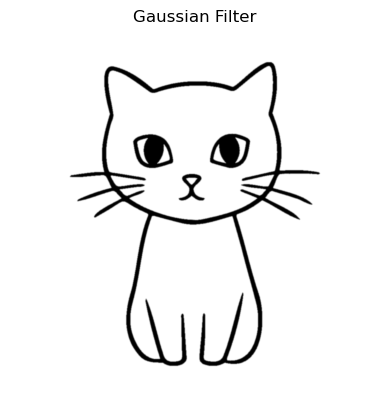

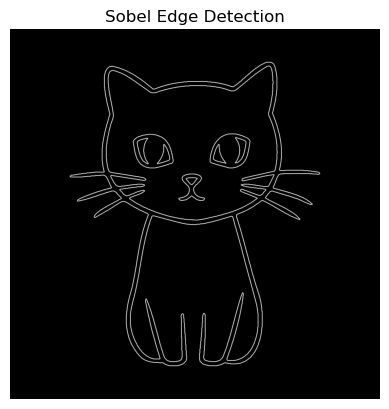

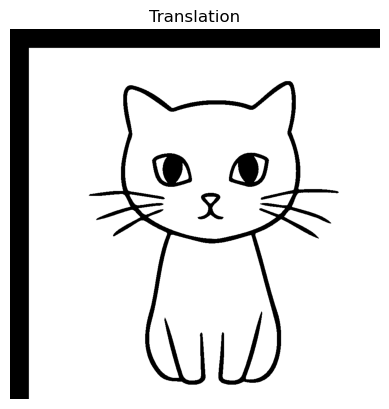

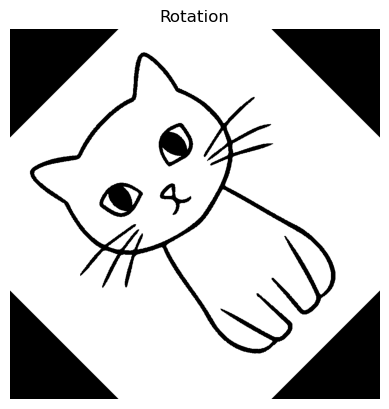

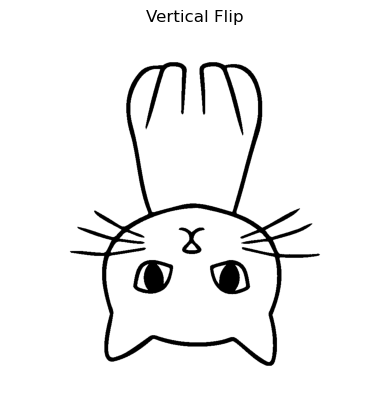

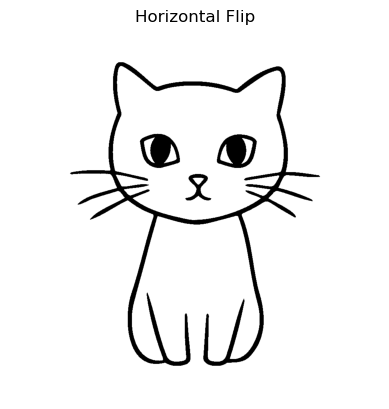

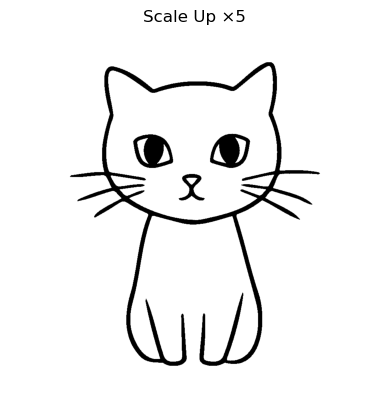

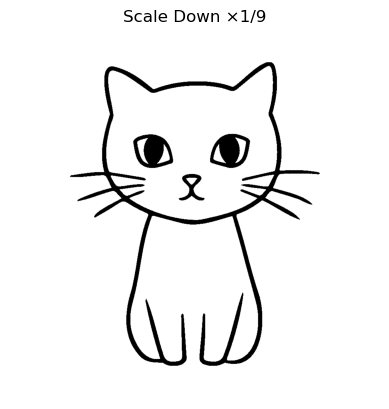

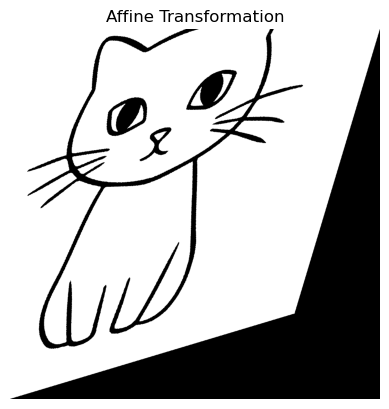

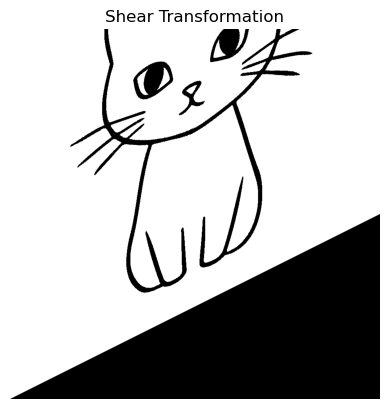

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import rotate, affine_transform, gaussian_filter, sobel

class ImageTransformation:

    def __init__(self, image_path):

        img = Image.open(image_path)
        gray = img.convert("L")

        self.image = np.array(gray)

        # Convert to binary
        self.binary = np.where(self.image > 128, 1, 0)

        print("Binary Image Matrix:\n")
        print(self.binary)

        plt.imshow(self.binary, cmap='gray')
        plt.title("Binary Image")
        plt.axis("off")
        plt.show()

    # ---------------- POINT FILTER ----------------
    def point_filter(self):
        inverted = 1 - self.binary

        plt.imshow(inverted, cmap='gray')
        plt.title("Point Filter (Invert)")
        plt.axis("off")
        plt.show()

    # ---------------- MEAN FILTER ----------------
    def mean_filter(self):

        result = np.zeros_like(self.binary, dtype=float)

        for i in range(1, self.binary.shape[0]-1):
            for j in range(1, self.binary.shape[1]-1):

                neighborhood = self.binary[i-1:i+2, j-1:j+2]
                result[i,j] = np.mean(neighborhood)

        plt.imshow(result, cmap='gray')
        plt.title("Mean Filter")
        plt.axis("off")
        plt.show()

    # ---------------- MEDIAN FILTER ----------------
    def median_filter(self):

        result = np.zeros_like(self.binary)

        for i in range(1, self.binary.shape[0]-1):
            for j in range(1, self.binary.shape[1]-1):

                neighborhood = self.binary[i-1:i+2, j-1:j+2]
                result[i,j] = np.median(neighborhood)

        plt.imshow(result, cmap='gray')
        plt.title("Median Filter")
        plt.axis("off")
        plt.show()

    # ---------------- GAUSSIAN FILTER ----------------
    def gaussian_filter(self):

        result = gaussian_filter(self.binary.astype(float), sigma=1)

        plt.imshow(result, cmap='gray')
        plt.title("Gaussian Filter")
        plt.axis("off")
        plt.show()

    # ---------------- SOBEL FILTER ----------------
    def sobel_filter(self):

        sx = sobel(self.binary, axis=0)
        sy = sobel(self.binary, axis=1)

        sobel_img = np.hypot(sx, sy)

        plt.imshow(sobel_img, cmap='gray')
        plt.title("Sobel Edge Detection")
        plt.axis("off")
        plt.show()

    # ---------------- TRANSLATION ----------------
    def translation(self, tx=50, ty=50):

        translated = np.zeros_like(self.binary)

        rows, cols = self.binary.shape

        for i in range(rows):
            for j in range(cols):

                if i+tx < rows and j+ty < cols:
                    translated[i+tx, j+ty] = self.binary[i,j]

        plt.imshow(translated, cmap='gray')
        plt.title("Translation")
        plt.axis("off")
        plt.show()

    # ---------------- ROTATION ----------------
    def rotation(self, angle=45):

        rotated = rotate(self.binary, angle, reshape=False)

        plt.imshow(rotated, cmap='gray')
        plt.title("Rotation")
        plt.axis("off")
        plt.show()

    # ---------------- VERTICAL FLIP ----------------
    def vertical_flip(self):

        flipped = np.flipud(self.binary)

        plt.imshow(flipped, cmap='gray')
        plt.title("Vertical Flip")
        plt.axis("off")
        plt.show()

    # ---------------- HORIZONTAL FLIP ----------------
    def horizontal_flip(self):

        flipped = np.fliplr(self.binary)

        plt.imshow(flipped, cmap='gray')
        plt.title("Horizontal Flip")
        plt.axis("off")
        plt.show()

    # ---------------- SCALE UP ----------------
    def scale_up(self):

        scaled = self.binary * 5

        plt.imshow(scaled, cmap='gray')
        plt.title("Scale Up ×5")
        plt.axis("off")
        plt.show()

    # ---------------- SCALE DOWN ----------------
    def scale_down(self):

        scaled = self.binary * (1/9)

        plt.imshow(scaled, cmap='gray')
        plt.title("Scale Down ×1/9")
        plt.axis("off")
        plt.show()

    # ---------------- AFFINE TRANSFORMATION ----------------
    def affine(self):

        matrix = np.array([[1,0.3],[0.3,1]])

        affine_img = affine_transform(self.binary, matrix)

        plt.imshow(affine_img, cmap='gray')
        plt.title("Affine Transformation")
        plt.axis("off")
        plt.show()

    # ---------------- SHEAR ----------------
    def shear(self):

        shear_matrix = np.array([[1,0.5],[0,1]])

        shear_img = affine_transform(self.binary, shear_matrix)

        plt.imshow(shear_img, cmap='gray')
        plt.title("Shear Transformation")
        plt.axis("off")
        plt.show()


# ---------------- MAIN PROGRAM ----------------

image_path = r"C:\\Users\\soumy\\Downloads\\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

img = ImageTransformation(image_path)

img.point_filter()
img.mean_filter()
img.median_filter()
img.gaussian_filter()
img.sobel_filter()

img.translation()
img.rotation()
img.vertical_flip()
img.horizontal_flip()

img.scale_up()
img.scale_down()

img.affine()
img.shear()


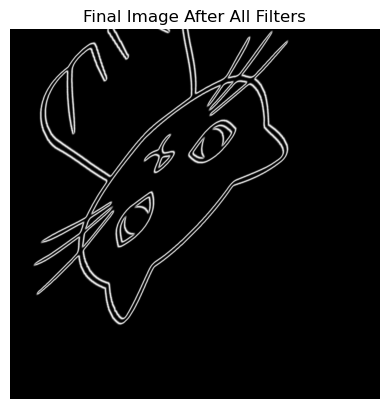

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import rotate, affine_transform, gaussian_filter, sobel

class CombinedImageFilter:

    def __init__(self, image_path):
        img = Image.open(image_path)
        gray = img.convert("L")
        self.image = np.array(gray)

        # Convert to binary
        self.processed = np.where(self.image > 128, 1.0, 0.0)

    def apply_all_filters(self):

        img = self.processed.copy()

        # -------- 1. POINT FILTER (Invert) --------
        img = 1 - img

        # -------- 2. MEAN FILTER --------
        mean_img = np.zeros_like(img)
        for i in range(1, img.shape[0]-1):
            for j in range(1, img.shape[1]-1):
                mean_img[i, j] = np.mean(img[i-1:i+2, j-1:j+2])
        img = mean_img

        # -------- 3. MEDIAN FILTER --------
        median_img = np.zeros_like(img)
        for i in range(1, img.shape[0]-1):
            for j in range(1, img.shape[1]-1):
                median_img[i, j] = np.median(img[i-1:i+2, j-1:j+2])
        img = median_img

        # -------- 4. GAUSSIAN FILTER --------
        img = gaussian_filter(img, sigma=1)

        # -------- 5. SOBEL FILTER --------
        sx = sobel(img, axis=0)
        sy = sobel(img, axis=1)
        img = np.hypot(sx, sy)

        # -------- 6. TRANSLATION --------
        translated = np.zeros_like(img)
        tx, ty = 30, 30
        rows, cols = img.shape

        for i in range(rows):
            for j in range(cols):
                if i+tx < rows and j+ty < cols:
                    translated[i+tx, j+ty] = img[i, j]
        img = translated

        # -------- 7. ROTATION --------
        img = rotate(img, angle=30, reshape=False)

        # -------- 8. FLIPS --------
        img = np.flipud(img)
        img = np.fliplr(img)

        # -------- 9. SCALING --------
        img = img * 2   # scale up

        # -------- 10. AFFINE --------
        matrix = np.array([[1, 0.2], [0.2, 1]])
        img = affine_transform(img, matrix)

        # -------- 11. SHEAR --------
        shear_matrix = np.array([[1, 0.3], [0, 1]])
        img = affine_transform(img, shear_matrix)

        # -------- FINAL OUTPUT --------
        plt.imshow(img, cmap='gray')
        plt.title("Final Image After All Filters")
        plt.axis("off")
        plt.show()


# -------- MAIN --------
image_path = r"C:\Users\soumy\Downloads\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

obj = CombinedImageFilter(image_path)
obj.apply_all_filters()


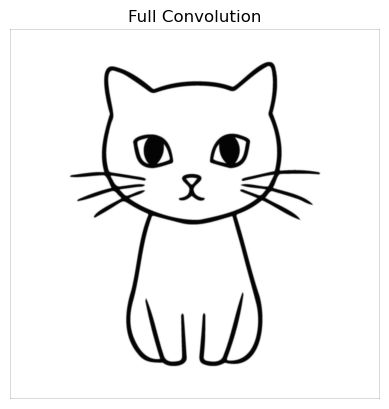

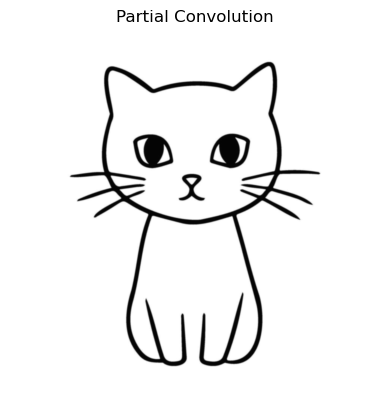

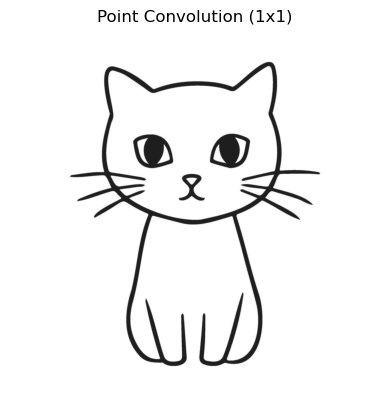

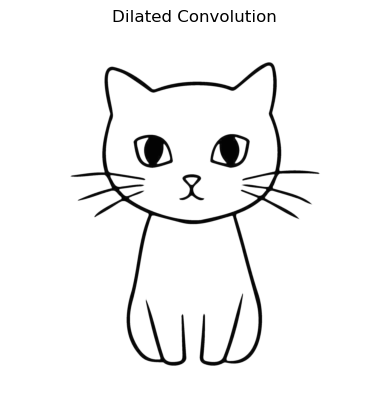

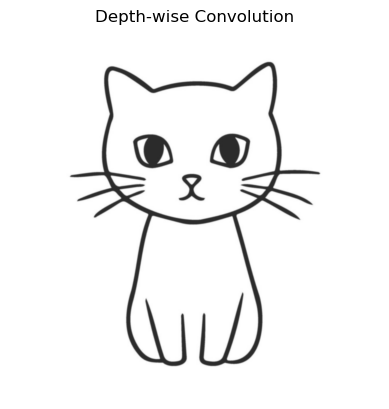

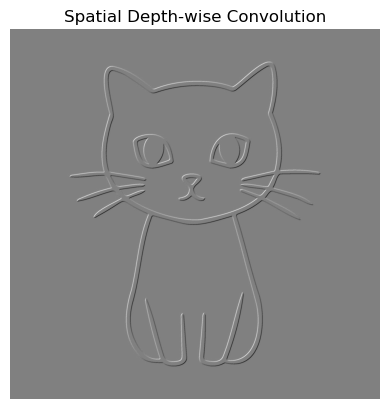

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- FULL CONVOLUTION ----------------
    def full_convolution(self):
        kernel = np.ones((3,3), dtype=np.float32) / 9
        result = cv2.filter2D(self.image, -1, kernel, borderType=cv2.BORDER_CONSTANT)
        self.show(result, "Full Convolution")

    # ---------------- PARTIAL CONVOLUTION ----------------
    def partial_convolution(self):
        kernel = np.ones((3,3), dtype=np.float32) / 9
        mask = (self.image > 0).astype(np.float32)

        conv = cv2.filter2D(self.image, -1, kernel)
        mask_conv = cv2.filter2D(mask, -1, kernel)

        result = conv / (mask_conv + 1e-5)
        self.show(result, "Partial Convolution")

    # ---------------- POINT CONVOLUTION (1x1) ----------------
    def point_convolution(self):
        kernel = np.array([[2]], dtype=np.float32)
        result = cv2.filter2D(self.image, -1, kernel)
        self.show(result, "Point Convolution (1x1)")

    # ---------------- DILATED CONVOLUTION (FIXED) ----------------
    def dilated_convolution(self):
        kernel = np.array([[1,0,1],
                           [0,1,0],
                           [1,0,1]], dtype=np.uint8)

        # Convert image to uint8
        img_uint8 = (self.image * 255).astype(np.uint8)

        result = cv2.dilate(img_uint8, kernel)

        # Convert back to float for display
        result = result / 255.0

        self.show(result, "Dilated Convolution")

    # ---------------- DEPTH-WISE CONVOLUTION ----------------
    def depthwise_convolution(self):
        img_color = cv2.cvtColor((self.image*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        kernel = np.ones((3,3), dtype=np.float32) / 9

        channels = cv2.split(img_color)
        result_channels = []

        for ch in channels:
            result_channels.append(cv2.filter2D(ch, -1, kernel))

        result = cv2.merge(result_channels)
        self.show(result, "Depth-wise Convolution")

    # ---------------- SPATIAL DEPTH-WISE CONVOLUTION ----------------
    def spatial_depthwise(self):
        kernel_h = np.array([[1, 0, -1]], dtype=np.float32)
        kernel_v = np.array([[1], [0], [-1]], dtype=np.float32)

        conv_h = cv2.filter2D(self.image, -1, kernel_h)
        conv_v = cv2.filter2D(self.image, -1, kernel_v)

        result = conv_h + conv_v
        self.show(result, "Spatial Depth-wise Convolution")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

obj = ConvolutionTypes(image_path)

obj.full_convolution()
obj.partial_convolution()
obj.point_convolution()
obj.dilated_convolution()   # ✅ Now works without error
obj.depthwise_convolution()
obj.spatial_depthwise()

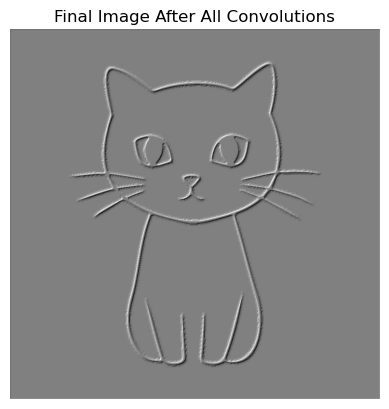

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- PIPELINE FUNCTION ----------------
    def apply_all_convolutions(self):

        img = self.image.copy()

        # -------- 1. FULL CONVOLUTION --------
        kernel = np.ones((3,3), dtype=np.float32) / 9
        img = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_CONSTANT)

        # -------- 2. PARTIAL CONVOLUTION --------
        mask = (img > 0).astype(np.float32)
        conv = cv2.filter2D(img, -1, kernel)
        mask_conv = cv2.filter2D(mask, -1, kernel)
        img = conv / (mask_conv + 1e-5)

        # -------- 3. POINT CONVOLUTION --------
        point_kernel = np.array([[2]], dtype=np.float32)
        img = cv2.filter2D(img, -1, point_kernel)

        # -------- 4. DILATED CONVOLUTION (FIXED) --------
        kernel_dilate = np.array([[1,0,1],
                                 [0,1,0],
                                 [1,0,1]], dtype=np.uint8)

        img_uint8 = (img * 255).astype(np.uint8)
        img_uint8 = cv2.dilate(img_uint8, kernel_dilate)
        img = img_uint8 / 255.0

        # -------- 5. DEPTH-WISE CONVOLUTION --------
        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        kernel_dw = np.ones((3,3), dtype=np.float32) / 9

        channels = cv2.split(img_color)
        processed_channels = []

        for ch in channels:
            processed_channels.append(cv2.filter2D(ch, -1, kernel_dw))

        img = cv2.merge(processed_channels)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0

        # -------- 6. SPATIAL DEPTH-WISE --------
        kernel_h = np.array([[1, 0, -1]], dtype=np.float32)
        kernel_v = np.array([[1], [0], [-1]], dtype=np.float32)

        conv_h = cv2.filter2D(img, -1, kernel_h)
        conv_v = cv2.filter2D(img, -1, kernel_v)

        img = conv_h + conv_v

        # -------- FINAL OUTPUT --------
        self.show(img, "Final Image After All Convolutions")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

obj = ConvolutionTypes(image_path)
obj.apply_all_convolutions()

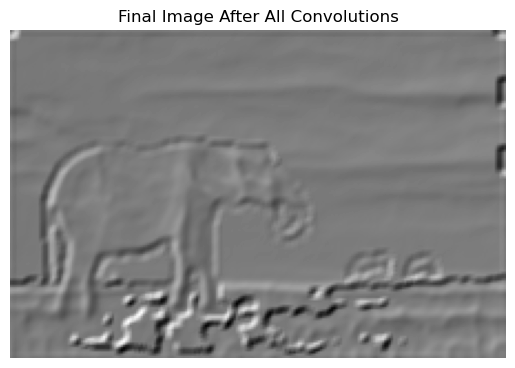

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- PIPELINE FUNCTION ----------------
    def apply_all_convolutions(self):

        img = self.image.copy()

        # -------- 1. FULL CONVOLUTION --------
        kernel = np.ones((3,3), dtype=np.float32) / 9
        img = cv2.filter2D(img, -1, kernel, borderType=cv2.BORDER_CONSTANT)

        # -------- 2. PARTIAL CONVOLUTION --------
        mask = (img > 0).astype(np.float32)
        conv = cv2.filter2D(img, -1, kernel)
        mask_conv = cv2.filter2D(mask, -1, kernel)
        img = conv / (mask_conv + 1e-5)

        # -------- 3. POINT CONVOLUTION --------
        point_kernel = np.array([[2]], dtype=np.float32)
        img = cv2.filter2D(img, -1, point_kernel)

        # -------- 4. DILATED CONVOLUTION (FIXED) --------
        kernel_dilate = np.array([[1,0,1],
                                 [0,1,0],
                                 [1,0,1]], dtype=np.uint8)

        img_uint8 = (img * 255).astype(np.uint8)
        img_uint8 = cv2.dilate(img_uint8, kernel_dilate)
        img = img_uint8 / 255.0

        # -------- 5. DEPTH-WISE CONVOLUTION --------
        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        kernel_dw = np.ones((3,3), dtype=np.float32) / 9

        channels = cv2.split(img_color)
        processed_channels = []

        for ch in channels:
            processed_channels.append(cv2.filter2D(ch, -1, kernel_dw))

        img = cv2.merge(processed_channels)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) / 255.0

        # -------- 6. SPATIAL DEPTH-WISE --------
        kernel_h = np.array([[1, 0, -1]], dtype=np.float32)
        kernel_v = np.array([[1], [0], [-1]], dtype=np.float32)

        conv_h = cv2.filter2D(img, -1, kernel_h)
        conv_v = cv2.filter2D(img, -1, kernel_v)

        img = conv_h + conv_v

        # -------- FINAL OUTPUT --------
        self.show(img, "Final Image After All Convolutions")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\download elephant.jpg"

obj = ConvolutionTypes(image_path)
obj.apply_all_convolutions()

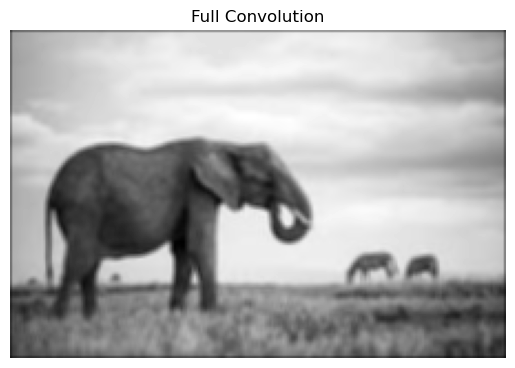

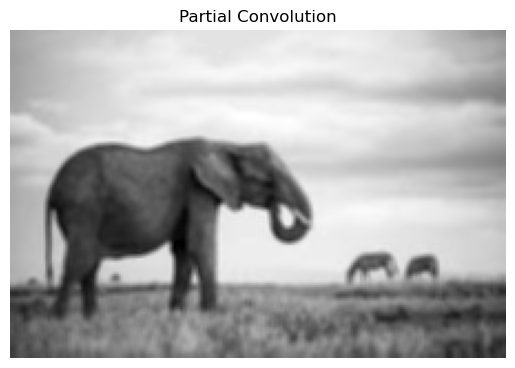

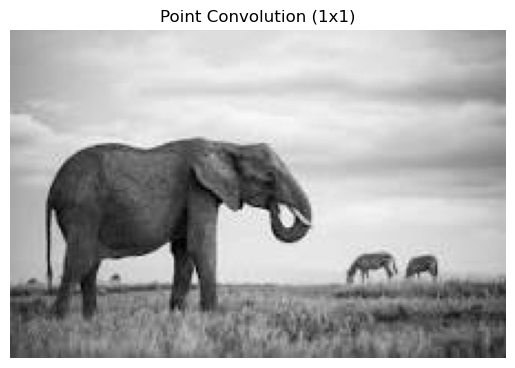

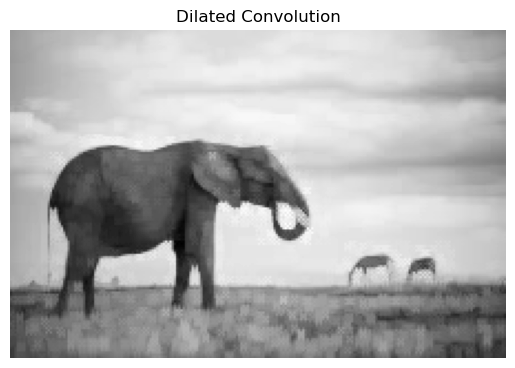

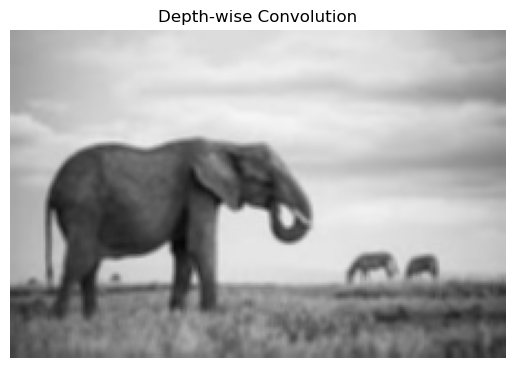

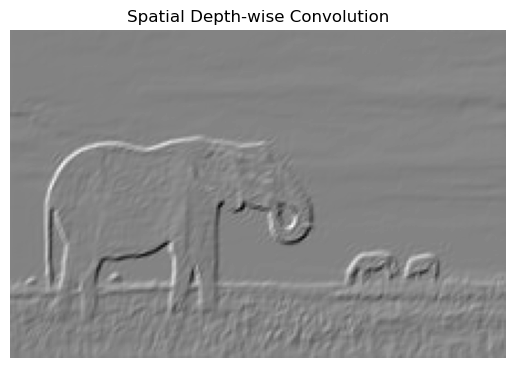

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- FULL CONVOLUTION ----------------
    def full_convolution(self):
        kernel = np.ones((3,3), dtype=np.float32) / 9
        result = cv2.filter2D(self.image, -1, kernel, borderType=cv2.BORDER_CONSTANT)
        self.show(result, "Full Convolution")

    # ---------------- PARTIAL CONVOLUTION ----------------
    def partial_convolution(self):
        kernel = np.ones((3,3), dtype=np.float32) / 9
        mask = (self.image > 0).astype(np.float32)

        conv = cv2.filter2D(self.image, -1, kernel)
        mask_conv = cv2.filter2D(mask, -1, kernel)

        result = conv / (mask_conv + 1e-5)
        self.show(result, "Partial Convolution")

    # ---------------- POINT CONVOLUTION (1x1) ----------------
    def point_convolution(self):
        kernel = np.array([[2]], dtype=np.float32)
        result = cv2.filter2D(self.image, -1, kernel)
        self.show(result, "Point Convolution (1x1)")

    # ---------------- DILATED CONVOLUTION (FIXED) ----------------
    def dilated_convolution(self):
        kernel = np.array([[1,0,1],
                           [0,1,0],
                           [1,0,1]], dtype=np.uint8)

        # Convert image to uint8
        img_uint8 = (self.image * 255).astype(np.uint8)

        result = cv2.dilate(img_uint8, kernel)

        # Convert back to float for display
        result = result / 255.0

        self.show(result, "Dilated Convolution")

    # ---------------- DEPTH-WISE CONVOLUTION ----------------
    def depthwise_convolution(self):
        img_color = cv2.cvtColor((self.image*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        kernel = np.ones((3,3), dtype=np.float32) / 9

        channels = cv2.split(img_color)
        result_channels = []

        for ch in channels:
            result_channels.append(cv2.filter2D(ch, -1, kernel))

        result = cv2.merge(result_channels)
        self.show(result, "Depth-wise Convolution")

    # ---------------- SPATIAL DEPTH-WISE CONVOLUTION ----------------
    def spatial_depthwise(self):
        kernel_h = np.array([[1, 0, -1]], dtype=np.float32)
        kernel_v = np.array([[1], [0], [-1]], dtype=np.float32)

        conv_h = cv2.filter2D(self.image, -1, kernel_h)
        conv_v = cv2.filter2D(self.image, -1, kernel_v)

        result = conv_h + conv_v
        self.show(result, "Spatial Depth-wise Convolution")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\download elephant.jpg"

obj = ConvolutionTypes(image_path)

obj.full_convolution()
obj.partial_convolution()
obj.point_convolution()
obj.dilated_convolution()   # ✅ Now works without error
obj.depthwise_convolution()
obj.spatial_depthwise()

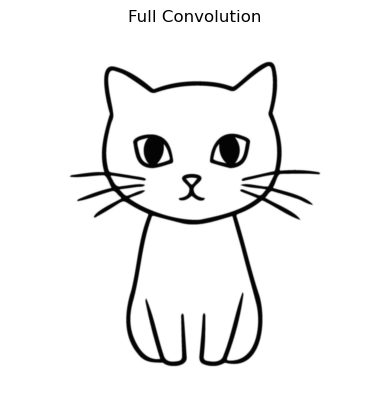

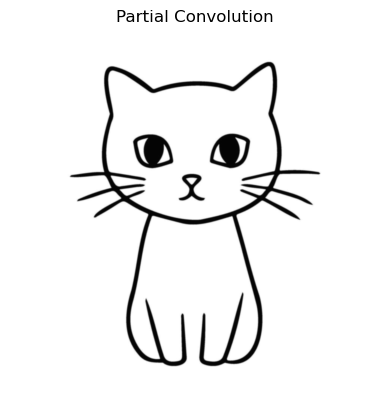

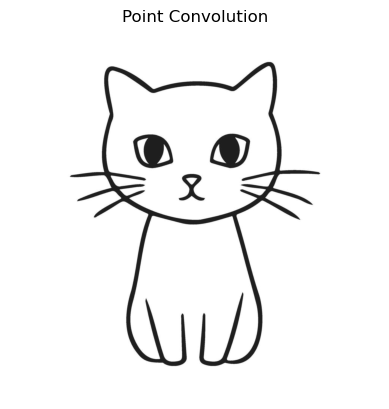

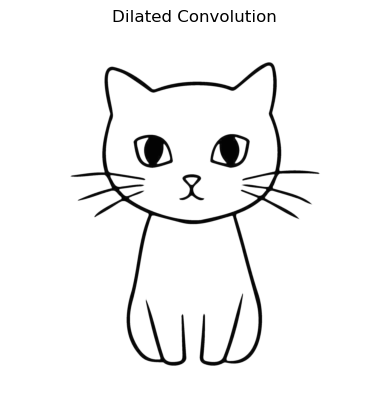

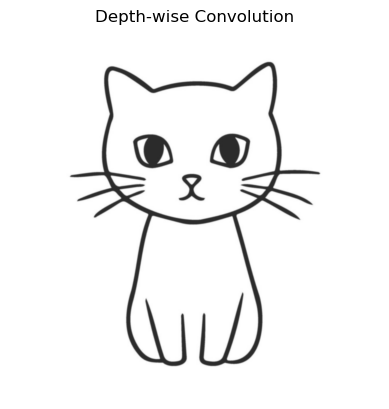

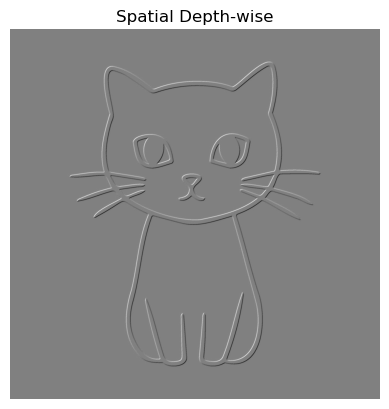

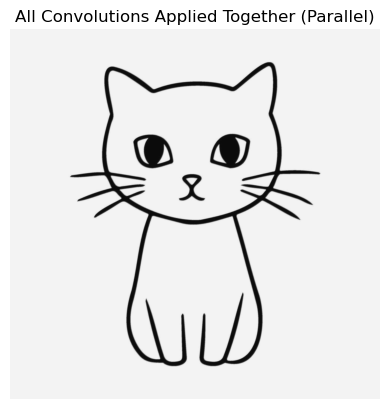

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- INDIVIDUAL CONVOLUTIONS ----------------
    def apply_individual(self):

        img = self.image

        # Full
        k = np.ones((3,3), dtype=np.float32)/9
        full = cv2.filter2D(img, -1, k)
        self.show(full, "Full Convolution")

        # Partial
        mask = (img > 0).astype(np.float32)
        conv = cv2.filter2D(img, -1, k)
        mask_conv = cv2.filter2D(mask, -1, k)
        partial = conv / (mask_conv + 1e-5)
        self.show(partial, "Partial Convolution")

        # Point
        point = cv2.filter2D(img, -1, np.array([[2]], dtype=np.float32))
        self.show(point, "Point Convolution")

        # Dilated
        kernel_d = np.array([[1,0,1],[0,1,0],[1,0,1]], dtype=np.uint8)
        dilated = cv2.dilate((img*255).astype(np.uint8), kernel_d) / 255.0
        self.show(dilated, "Dilated Convolution")

        # Depth-wise
        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        channels = cv2.split(img_color)
        dw = [cv2.filter2D(ch, -1, k) for ch in channels]
        depthwise = cv2.merge(dw)
        self.show(depthwise, "Depth-wise Convolution")

        # Spatial depth-wise
        kh = np.array([[1,0,-1]], dtype=np.float32)
        kv = np.array([[1],[0],[-1]], dtype=np.float32)
        spatial = cv2.filter2D(img, -1, kh) + cv2.filter2D(img, -1, kv)
        self.show(spatial, "Spatial Depth-wise")

    # ---------------- PARALLEL COMBINED ----------------
    def apply_all_parallel(self):

        img = self.image
        k = np.ones((3,3), dtype=np.float32)/9

        # Individual outputs
        full = cv2.filter2D(img, -1, k)

        mask = (img > 0).astype(np.float32)
        partial = cv2.filter2D(img, -1, k) / (cv2.filter2D(mask, -1, k) + 1e-5)

        point = cv2.filter2D(img, -1, np.array([[2]], dtype=np.float32))

        kernel_d = np.array([[1,0,1],[0,1,0],[1,0,1]], dtype=np.uint8)
        dilated = cv2.dilate((img*255).astype(np.uint8), kernel_d) / 255.0

        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        channels = cv2.split(img_color)
        dw = [cv2.filter2D(ch, -1, k) for ch in channels]
        depthwise = cv2.cvtColor(cv2.merge(dw), cv2.COLOR_BGR2GRAY) / 255.0

        kh = np.array([[1,0,-1]], dtype=np.float32)
        kv = np.array([[1],[0],[-1]], dtype=np.float32)
        spatial = cv2.filter2D(img, -1, kh) + cv2.filter2D(img, -1, kv)

        # -------- COMBINE ALL RESULTS --------
        combined = (full + partial + point + dilated + depthwise + spatial) / 6.0

        self.show(combined, "All Convolutions Applied Together (Parallel)")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\simple-black-and-white-line-drawing-of-a-sitting-cat-vector.jpg"

obj = ConvolutionTypes(image_path)

# ✅ Individual outputs
obj.apply_individual()

# ✅ All applied together (parallel)
obj.apply_all_parallel()

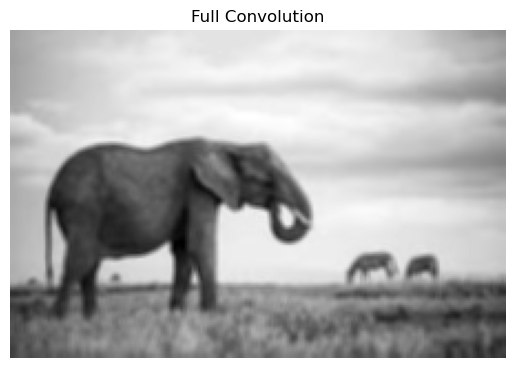

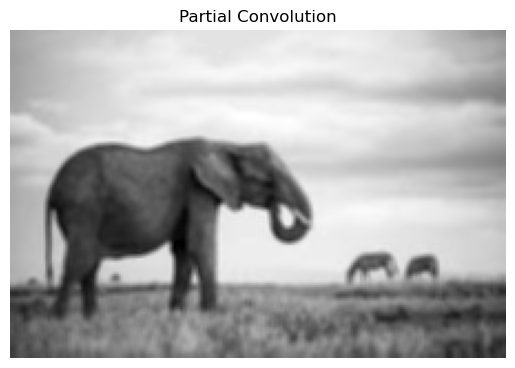

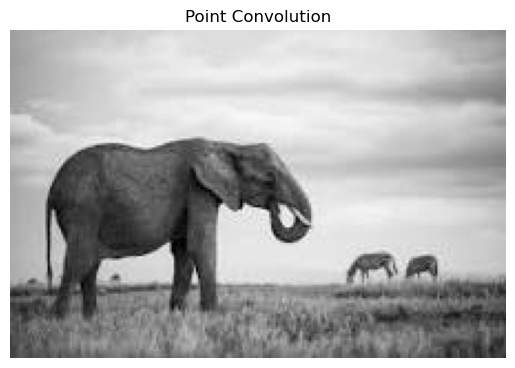

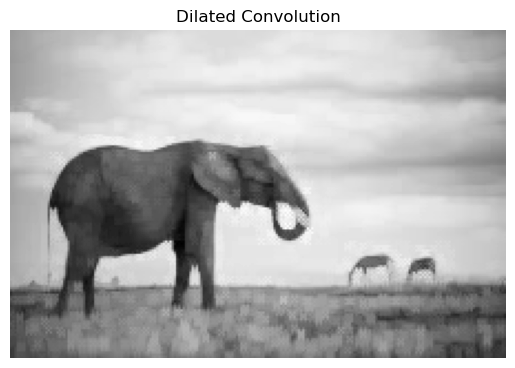

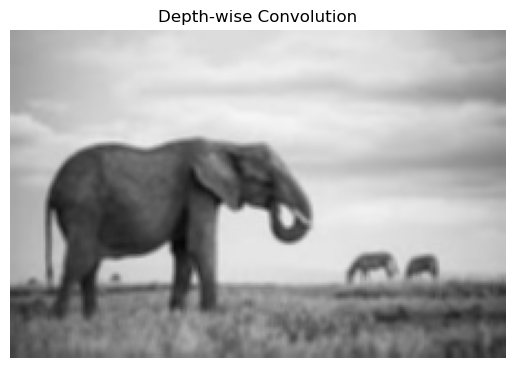

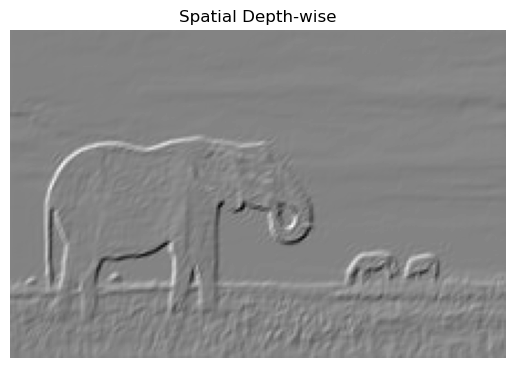

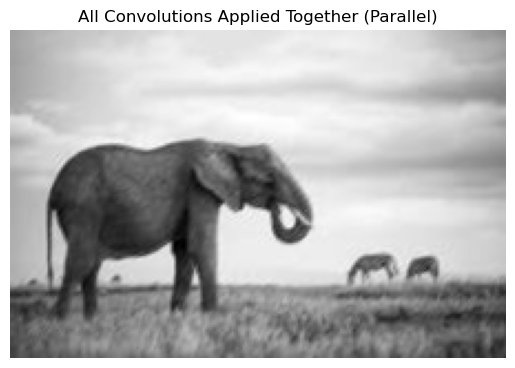

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

class ConvolutionTypes:

    def __init__(self, image_path):
        img = Image.open(image_path).convert("L")
        self.image = np.array(img) / 255.0   # normalize

    def show(self, img, title):
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis("off")
        plt.show()

    # ---------------- INDIVIDUAL CONVOLUTIONS ----------------
    def apply_individual(self):

        img = self.image

        # Full
        k = np.ones((3,3), dtype=np.float32)/9
        full = cv2.filter2D(img, -1, k)
        self.show(full, "Full Convolution")

        # Partial
        mask = (img > 0).astype(np.float32)
        conv = cv2.filter2D(img, -1, k)
        mask_conv = cv2.filter2D(mask, -1, k)
        partial = conv / (mask_conv + 1e-5)
        self.show(partial, "Partial Convolution")

        # Point
        point = cv2.filter2D(img, -1, np.array([[2]], dtype=np.float32))
        self.show(point, "Point Convolution")

        # Dilated
        kernel_d = np.array([[1,0,1],[0,1,0],[1,0,1]], dtype=np.uint8)
        dilated = cv2.dilate((img*255).astype(np.uint8), kernel_d) / 255.0
        self.show(dilated, "Dilated Convolution")

        # Depth-wise
        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        channels = cv2.split(img_color)
        dw = [cv2.filter2D(ch, -1, k) for ch in channels]
        depthwise = cv2.merge(dw)
        self.show(depthwise, "Depth-wise Convolution")

        # Spatial depth-wise
        kh = np.array([[1,0,-1]], dtype=np.float32)
        kv = np.array([[1],[0],[-1]], dtype=np.float32)
        spatial = cv2.filter2D(img, -1, kh) + cv2.filter2D(img, -1, kv)
        self.show(spatial, "Spatial Depth-wise")

    # ---------------- PARALLEL COMBINED ----------------
    def apply_all_parallel(self):

        img = self.image
        k = np.ones((3,3), dtype=np.float32)/9

        # Individual outputs
        full = cv2.filter2D(img, -1, k)

        mask = (img > 0).astype(np.float32)
        partial = cv2.filter2D(img, -1, k) / (cv2.filter2D(mask, -1, k) + 1e-5)

        point = cv2.filter2D(img, -1, np.array([[2]], dtype=np.float32))

        kernel_d = np.array([[1,0,1],[0,1,0],[1,0,1]], dtype=np.uint8)
        dilated = cv2.dilate((img*255).astype(np.uint8), kernel_d) / 255.0

        img_color = cv2.cvtColor((img*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
        channels = cv2.split(img_color)
        dw = [cv2.filter2D(ch, -1, k) for ch in channels]
        depthwise = cv2.cvtColor(cv2.merge(dw), cv2.COLOR_BGR2GRAY) / 255.0

        kh = np.array([[1,0,-1]], dtype=np.float32)
        kv = np.array([[1],[0],[-1]], dtype=np.float32)
        spatial = cv2.filter2D(img, -1, kh) + cv2.filter2D(img, -1, kv)

        # -------- COMBINE ALL RESULTS --------
        combined = (full + partial + point + dilated + depthwise + spatial) / 6.0

        self.show(combined, "All Convolutions Applied Together (Parallel)")


# ---------------- MAIN ----------------
image_path = r"C:\Users\soumy\Downloads\download elephant.jpg"

obj = ConvolutionTypes(image_path)

# ✅ Individual outputs
obj.apply_individual()

# ✅ All applied together (parallel)
obj.apply_all_parallel()